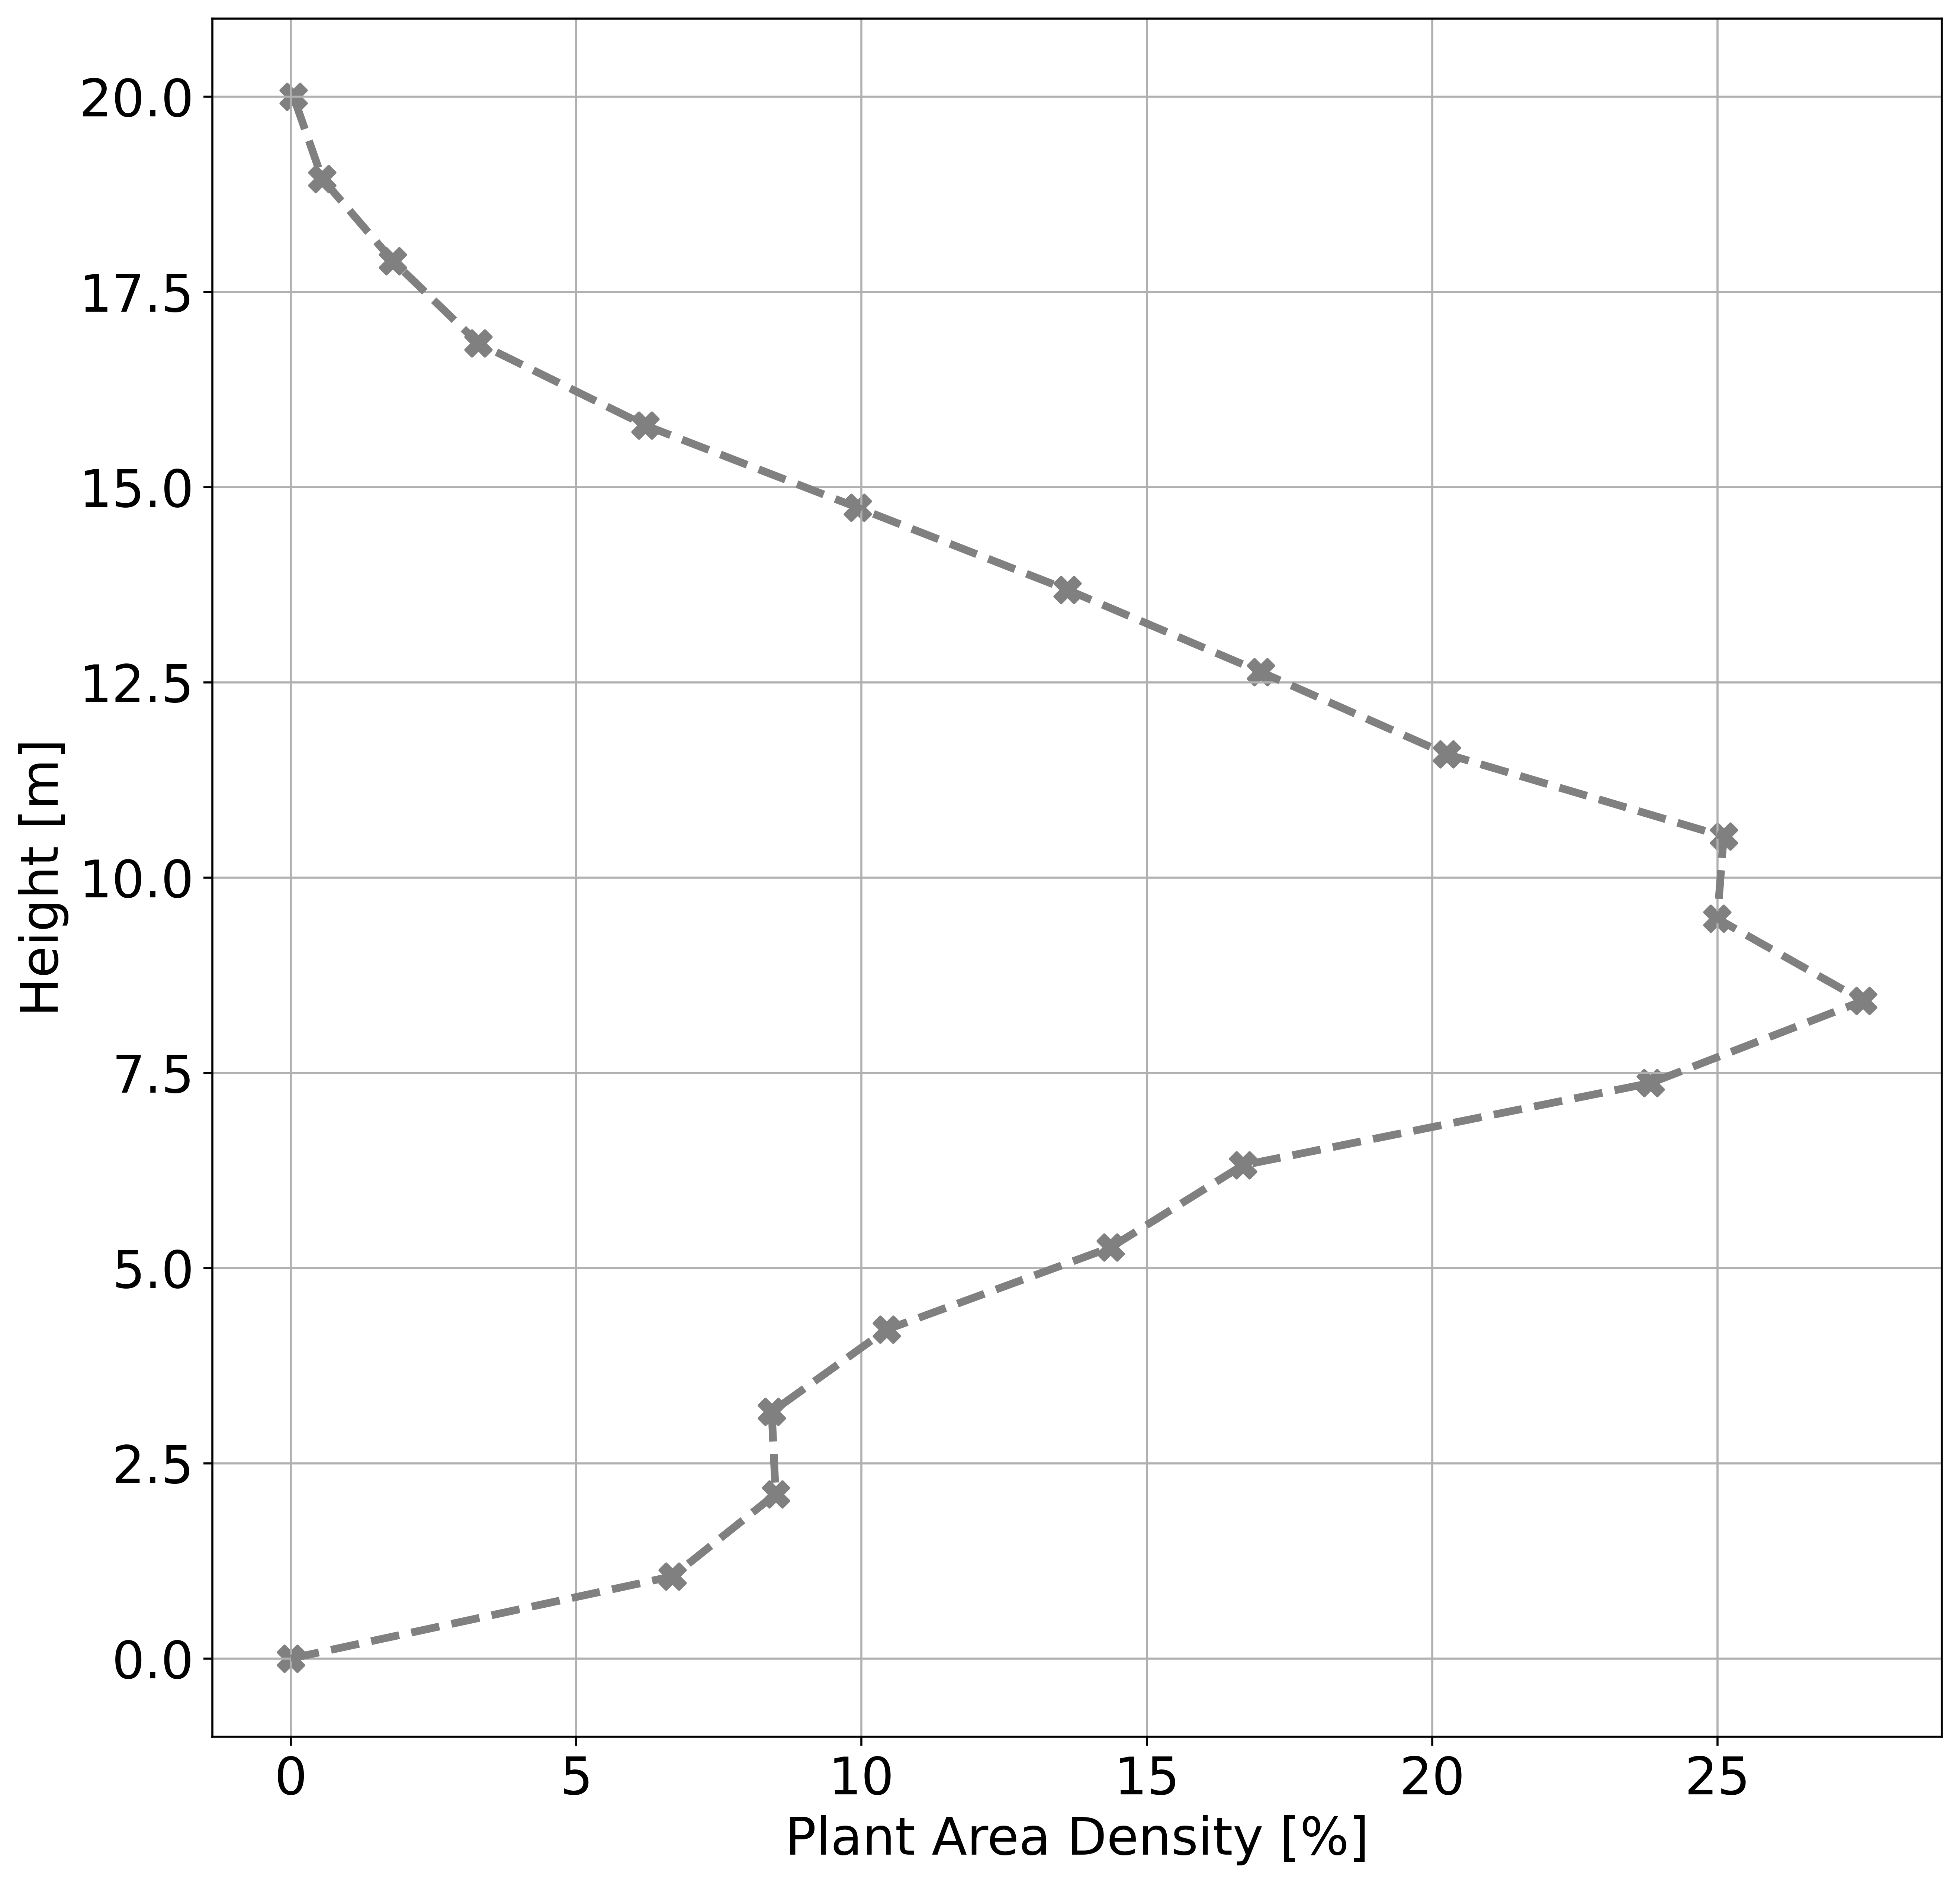

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data digitized using https://plotdigitizer.com/app, taken from area LA4 from fig, 4, paper:
# Estimation of vertical plant area density from single return terrestrial laser scanning point clouds acquired in forest environments, Nguyen et al., 2022

x = [0.0, 0.05812553740326741, 0.07566638005159071, 0.0828890799656062, 0.08701633705932932, 0.08426483233018056, 
     0.09561478933791917, 0.13069647463456577, 0.14411006018916594, 0.15614789337919174, 0.1582115219260533, 
     .26345657781599313, 0.2294067067927773, 0.2758383490971625, 0.027515047291487533, 0.017884780739466897, 
     0.017884780739466897, 0.017884780739466897, 0.017884780739466897, 0.10318142734307824, 0.1527085124677558, 
     0.1571797076526225, 0.19191745485812553, 0.20257953568357695, 0.22975064488392088, 0.24763542562338778, 
     0.17815993121238177, 0.13172828890799657, 0.13172828890799657, 0.0883920894239037, 0.0883920894239037, 
     0.06672398968185726, 0.06672398968185726, 0.04883920894239037, 0.04883920894239037, 0.007910576096302666, 
     0.006878761822871883, 0.0017196904557179708, 0.005503009458297506, -0.00034393809114359415, -0.0010318142734307824, 
     0, 0.03817712811693895, 0.07944969905417025, 0.1172828890799656, 0.14479793637145313, 0.2534823731728289, 
     0.2534823731728289, 0.2754944110060189, 0.2754944110060189, 0.2510748065348237, 0.2510748065348237, 
     0.23422184006878763, 0.21668099742046432, 0.17540842648323302, 0.11315563198624247]

y = [0.9776833156216791, 1.1477151965993624, 1.9553666312433582, 2.5929861849096705, 2.933049946865037, 
     3.7832093517534537, 4.314558979808714, 5.058448459086079, 5.334750265674814, 5.67481402763018, 
     6.227417640807651, 9.011689691817216, 9.373007438894794, 10.053134962805526, 16.705632306057385, 
     17.44952178533475, 17.44952178533475, 17.44952178533475, 17.44952178533475, 14.133900106269927, 
     12.75239107332625, 12.81615302869288, 12.242295430393199, 11.540913921360255, 10.860786397449521, 
     10.73326248671626, 12.709883103081829, 13.475026567481404, 13.475026567481404, 14.87778958554729, 
     14.87778958554729, 15.494155154091393, 15.494155154091393, 15.919234856535601, 15.919234856535601, 
     18.00212539851222, 18.172157279489905, 18.767268862911795, 18.533475026567483, 19.3836344314559, 
     19.638682252922422, 19.043570669500532, 16.34431455897981, 15.196599362380447, 14.091392136025505, 
     13.134962805526037, 9.606801275239107, 9.606801275239107, 8.374070138150904, 8.374070138150904, 
     7.8002125398512225, 7.8002125398512225, 7.18384697130712, 7.035069075451648, 6.588735387885229, 4.782146652497343]

height = y
pad = x
df = pd.DataFrame({"height": y, "pad": x})
bin_width = 1.0
df["height_bin"] = np.floor(df["height"] / bin_width)
pad_profile = abs(df.groupby("height_bin")["pad"].mean())

z = np.linspace(0,20,20)
plt.figure(figsize=(12,12),dpi=500)
plt.plot(pad_profile*100,z,linewidth=3, linestyle='dashed',color='gray')
plt.scatter(pad_profile*100,z,s=100,marker='X',color='grey')
plt.xlabel("Plant Area Density [%]",fontsize=20)
plt.ylabel('Height [m]',fontsize=20)
plt.tick_params(axis='both', labelsize=20)
plt.grid()

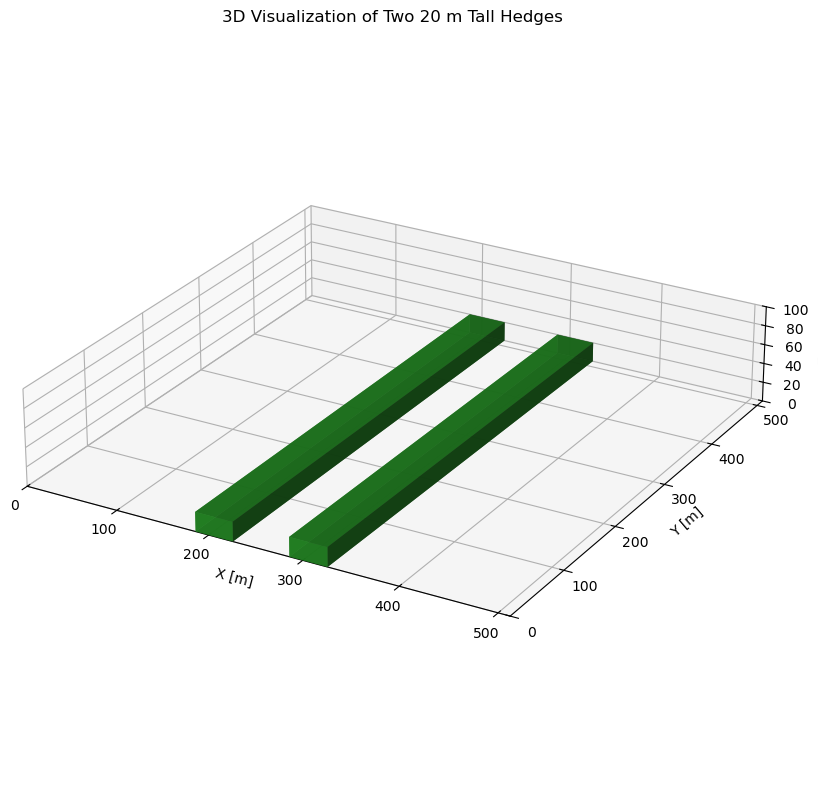

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# domain
x_lim = 512
y_lim = 512
z_lim = 100

# hedge parameters
hedge_distance = 60      # gap between hedges
hedge_width = 40         # hedge thickness in x
hedge_height = 20        # hedge height in z
hedge_length = y_lim     # full length in y

# center the two hedges in the domain
total_width = 2 * hedge_width + hedge_distance
x_start = (x_lim - total_width) / 2

# hedge x positions
hedge1_x = x_start
hedge2_x = x_start + hedge_width + hedge_distance

# create figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# hedge 1
ax.bar3d(
    hedge1_x,          # x start
    0,                 # y start
    0,                 # z start
    hedge_width,       # dx
    hedge_length,      # dy
    hedge_height,      # dz
    color='forestgreen',
    alpha=0.85,
    shade=True
)

# hedge 2
ax.bar3d(
    hedge2_x,
    0,
    0,
    hedge_width,
    hedge_length,
    hedge_height,
    color='forestgreen',
    alpha=0.85,
    shade=True
)

# axes
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Z [m]')

ax.set_xlim(0, x_lim)
ax.set_ylim(0, y_lim)
ax.set_zlim(0, z_lim)

# make vertical scale more realistic
ax.set_box_aspect((x_lim, y_lim, z_lim))

# viewing angle similar to terrain visualization
ax.view_init(elev=25, azim=-60)

ax.set_title('3D Visualization of Two 20 m Tall Hedges')

plt.tight_layout()
plt.show()